In [7]:
import pandas
import numpy
from tools import Average, add_error_bar
from matplotlib import pyplot as plt
from decimal import Decimal
import statistics

class AverageByMinMax(Average):
    @classmethod
    def from_min_max(cls, min_value: float, max_value: float) -> "AverageByMinMax": 
        diff = max_value - min_value
        if diff > 0 and not numpy.isclose(max_value, min_value):
            resolution = diff
        else:
            as_decimal = Decimal(str(max_value))
            decimal_count = as_decimal.as_tuple().exponent
            resolution = 10 ** decimal_count

        resolution_error = resolution / numpy.sqrt(12)
        mean = statistics.mean([min_value, max_value])
        return cls(mean=mean, total_error=resolution_error)



In [8]:
raw_measurements = pandas.read_csv("measurements.csv", delimiter="\t")

source_frequencies = []
source_voltages = []
resistor_voltages = []
voltages_divs = []

frequency_scale_factor = 1000 * 2 * numpy.pi

dict_list = []
for index, row in raw_measurements.iterrows():
    source_frequency = AverageByMinMax.from_min_max(min_value=row["freq min [kHz]"],max_value=row["freq max[kHz]"])
    source_frequency.mean = source_frequency.mean * frequency_scale_factor
    source_frequency.total_error = source_frequency.total_error * frequency_scale_factor
    
    source_frequencies.append(source_frequency)

    source_voltage = AverageByMinMax.from_min_max(min_value=row["ch-1 Vpp min[V]"],max_value=row["ch1-Vpp max[V]"])
    source_voltages.append(source_voltage)

    resistor_voltage = AverageByMinMax.from_min_max(min_value=row["ch2-Vpp min [V]"],max_value=row["ch2-Vpp max [V]"])
    resistor_voltages.append(resistor_voltage)

    voltages_div = resistor_voltage.mean/source_voltage.mean
    voltages_div_indirect_error = numpy.sqrt(
        (resistor_voltage.total_error/source_voltage.mean)**2
        + (
            (resistor_voltage.mean * source_voltage.total_error)
            / ((source_voltage.mean)**2)
        )**2
    )
    voltages_div = Average(mean=voltages_div, total_error=voltages_div_indirect_error)
    voltages_divs.append(voltages_div)

    dict_list.append({
        "frequency": source_frequency.mean,
        "frequency_error": source_frequency.total_error,
        "voltages_div": voltages_div.mean,
        "voltages_div_error": voltages_div.total_error
    })

as_df = pandas.DataFrame(dict_list)
print(as_df.to_csv(index=False))

frequency,frequency_error,voltages_div,voltages_div_error
6280.043714525997,1.8137993642342194,0.06813725490196079,0.0008504121088452968
12566.370614359172,181.37993642342178,0.15098039215686274,0.0011370882950208314
18849.55592153876,181.37993642342178,0.39215686274509803,0.002843717103103865
25132.741228718343,181.37993642342178,0.6616915422885573,0.0034442760044634453
31447.342462433826,18.13799364234179,0.2107843137254902,0.003701851854508315
21991.14857512855,181.37993642342178,0.8200000000000001,0.007466369041687291
23247.78563656447,181.37993642342178,0.92,0.007845168364456354
22619.46710584651,181.37993642342178,0.895,0.005918966689099267
22933.626371205486,18.137993642342177,0.92,0.00536042597809789
19509.290378792615,18.13799364234179,0.4430693069306931,0.0029080968759526682
20106.192982974677,181.37993642342178,0.5198019801980198,0.004122880141356717
20734.511513692632,181.37993642342178,0.6069651741293532,0.0018855365268034524
21394.245970946493,18.137993642342597,0.7064676

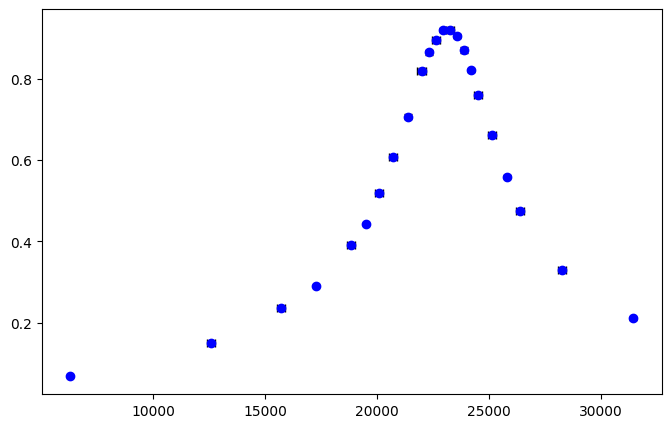

In [9]:
plt.figure(figsize=(8, 5))

add_error_bar(plot=plt, x=source_frequencies, y=voltages_divs, bar_config={
    "fmt": "o",
    "color": "blue",
    "ecolor": "black",
    "capsize": 3,
    "label": "Experimental Data"
})

plt.show()
